In [1]:
# Import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load Household Electricity Consumption Dataset
df = pd.read_csv(r'D:\PG\My data sets\power marketing dataset.csv')
# Display first five rows
df.head()

,record_id,customer_id,timestamp,hour,day_of_week,month,is_weekend,season,customer_type,age,...,ev_charging_kwh,electricity_consumption_kwh,pricing_influence_score,weather_influence_score,appliance_influence_score,household_influence_score,previous_hour_consumption_kwh,previous_day_same_hour_consumption_kwh,rolling_24h_avg_consumption_kwh,consumption_behavior_category
0,667,10001,2025-01-28 18:00:00,18,1,1,0,Winter,Small_Commercial,66,...,0.000,2.058,11.39,6.702,0.816,3.545,2.058,2.058,2.058,Moderate_Usage
1,778,10001,2025-02-02 09:00:00,9,6,2,1,Winter,Residential,38,...,0.000,1.253,5.94,4.538,0.590,3.955,2.058,1.656,1.656,Low_Usage
2,1011,10001,2025-02-12 02:00:00,2,2,2,0,Winter,Residential,26,...,1.225,3.607,3.44,11.739,2.738,4.461,1.253,2.306,2.306,Peak_Intensive_Usage
3,1170,10001,2025-02-18 17:00:00,17,1,2,0,Winter,Residential,59,...,0.000,0.662,2.48,5.061,0.280,2.652,3.607,1.895,1.895,Low_Usage
4,2037,10001,2025-03-26 20:00:00,20,2,3,0,Spring,Residential,38,...,0.000,1.496,0.95,3.762,0.701,4.412,0.662,1.815,1.815,Low_Usage


In [3]:
df.head()

,record_id,customer_id,timestamp,hour,day_of_week,month,is_weekend,season,customer_type,age,...,ev_charging_kwh,electricity_consumption_kwh,pricing_influence_score,weather_influence_score,appliance_influence_score,household_influence_score,previous_hour_consumption_kwh,previous_day_same_hour_consumption_kwh,rolling_24h_avg_consumption_kwh,consumption_behavior_category
0,667,10001,2025-01-28 18:00:00,18,1,1,0,Winter,Small_Commercial,66,...,0.000,2.058,11.39,6.702,0.816,3.545,2.058,2.058,2.058,Moderate_Usage
1,778,10001,2025-02-02 09:00:00,9,6,2,1,Winter,Residential,38,...,0.000,1.253,5.94,4.538,0.590,3.955,2.058,1.656,1.656,Low_Usage
2,1011,10001,2025-02-12 02:00:00,2,2,2,0,Winter,Residential,26,...,1.225,3.607,3.44,11.739,2.738,4.461,1.253,2.306,2.306,Peak_Intensive_Usage
3,1170,10001,2025-02-18 17:00:00,17,1,2,0,Winter,Residential,59,...,0.000,0.662,2.48,5.061,0.280,2.652,3.607,1.895,1.895,Low_Usage
4,2037,10001,2025-03-26 20:00:00,20,2,3,0,Spring,Residential,38,...,0.000,1.496,0.95,3.762,0.701,4.412,0.662,1.815,1.815,Low_Usage


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 38 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   record_id                               15000 non-null  int64  
 1   customer_id                             15000 non-null  int64  
 2   timestamp                               15000 non-null  object 
 3   hour                                    15000 non-null  int64  
 4   day_of_week                             15000 non-null  int64  
 5   month                                   15000 non-null  int64  
 6   is_weekend                              15000 non-null  int64  
 7   season                                  15000 non-null  object 
 8   customer_type                           15000 non-null  object 
 9   age                                     15000 non-null  int64  
 10  monthly_income_usd                      15000 non-null  in

In [5]:
df.isnull().sum()

record_id                                 0
customer_id                               0
timestamp                                 0
hour                                      0
day_of_week                               0
month                                     0
is_weekend                                0
season                                    0
customer_type                             0
age                                       0
monthly_income_usd                        0
household_size                            0
home_area_sqft                            0
appliance_count                           0
has_solar_panel                           0
has_ev                                    0
tariff_scheme                             0
contract_type                             0
temperature_c                             0
humidity_percent                          0
peak_hour                                 0
price_per_kwh                             0
ac_usage_hours                  

In [6]:
df.describe()

,record_id,customer_id,hour,day_of_week,month,is_weekend,age,monthly_income_usd,household_size,home_area_sqft,...,entertainment_usage_hours,ev_charging_kwh,electricity_consumption_kwh,pricing_influence_score,weather_influence_score,appliance_influence_score,household_influence_score,previous_hour_consumption_kwh,previous_day_same_hour_consumption_kwh,rolling_24h_avg_consumption_kwh
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,...,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7500.500000,10376.025200,11.500000,2.998400,5.816000,0.284800,48.521133,4099.846400,3.990933,1611.946200,...,0.329036,0.065368,2.002760,2.485628,6.330095,1.026010,4.204896,2.002417,1.993749,1.994318
std,4330.271354,216.437105,6.922417,1.997264,3.195063,0.451334,15.635293,2032.168958,1.992197,681.695097,...,0.244390,0.404672,0.717984,2.331150,4.066638,0.593636,1.094206,0.719083,0.329448,0.308493
min,1.000000,10001.000000,0.000000,0.000000,1.000000,0.000000,22.000000,600.000000,1.000000,450.000000,...,0.000000,0.000000,0.280000,0.000000,0.002000,0.079000,1.216000,0.280000,0.426000,0.426000
25%,3750.750000,10188.000000,5.750000,1.000000,3.000000,0.000000,35.000000,2346.500000,2.000000,1019.000000,...,0.143000,0.000000,1.485000,0.550000,3.161750,0.570000,3.430000,1.485000,1.822000,1.829000
50%,7500.500000,10378.000000,11.500000,3.000000,6.000000,0.000000,49.000000,4096.500000,4.000000,1601.000000,...,0.260000,0.000000,1.939000,1.810000,5.414000,0.921000,4.203000,1.939000,1.977000,1.978000
75%,11250.250000,10564.000000,17.250000,5.000000,8.000000,1.000000,62.000000,5874.250000,6.000000,2207.000000,...,0.508000,0.000000,2.397250,3.620000,9.002000,1.421000,4.986000,2.397000,2.136000,2.131000
max,15000.000000,10750.000000,23.000000,6.000000,12.000000,1.000000,75.000000,7599.000000,7.000000,2799.000000,...,1.000000,8.305000,9.379000,13.110000,19.528000,8.386000,7.248000,9.379000,6.115000,5.296000


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the structure of the dataset, identify patterns, detect relationships between variables, and gain insights before building the machine learning models. This analysis helps in selecting relevant features and understanding the factors that influence household electricity consumption.

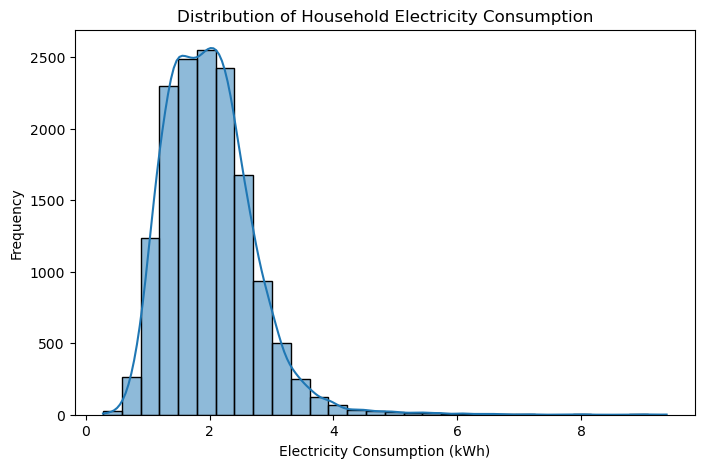

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(df["electricity_consumption_kwh"],
             bins=30,
             kde=True)

plt.title("Distribution of Household Electricity Consumption")

plt.xlabel("Electricity Consumption (kWh)")

plt.ylabel("Frequency")

plt.show()

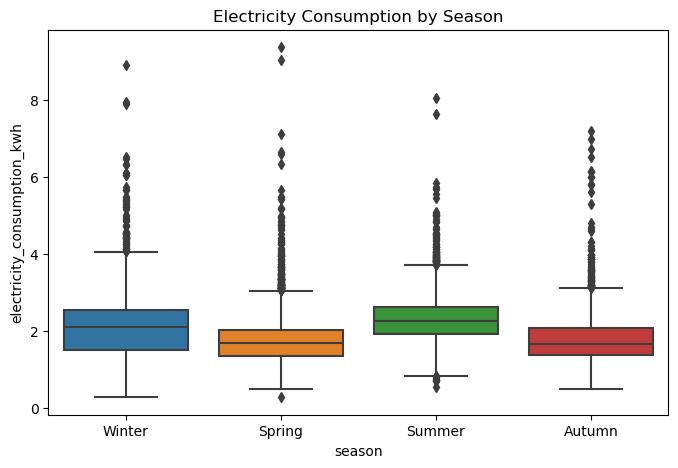

In [8]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="season",
    y="electricity_consumption_kwh",
    data=df
)

plt.title("Electricity Consumption by Season")

plt.show()

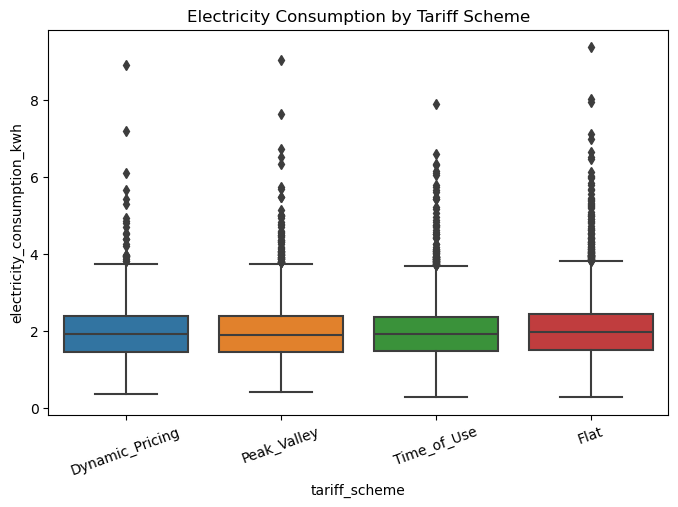

In [9]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="tariff_scheme",
    y="electricity_consumption_kwh",
    data=df
)

plt.title("Electricity Consumption by Tariff Scheme")

plt.xticks(rotation=20)

plt.show()

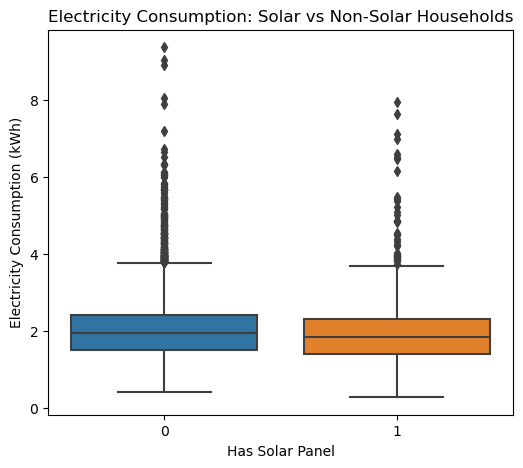

In [10]:
plt.figure(figsize=(6,5))

sns.boxplot(
    x="has_solar_panel",
    y="electricity_consumption_kwh",
    data=df
)

plt.title("Electricity Consumption: Solar vs Non-Solar Households")

plt.xlabel("Has Solar Panel")

plt.ylabel("Electricity Consumption (kWh)")

plt.show()

# Correlation Analysis

A correlation heatmap is used to identify the relationships between numerical variables in the dataset. Strong positive or negative correlations help identify the features that have the greatest influence on household electricity consumption.

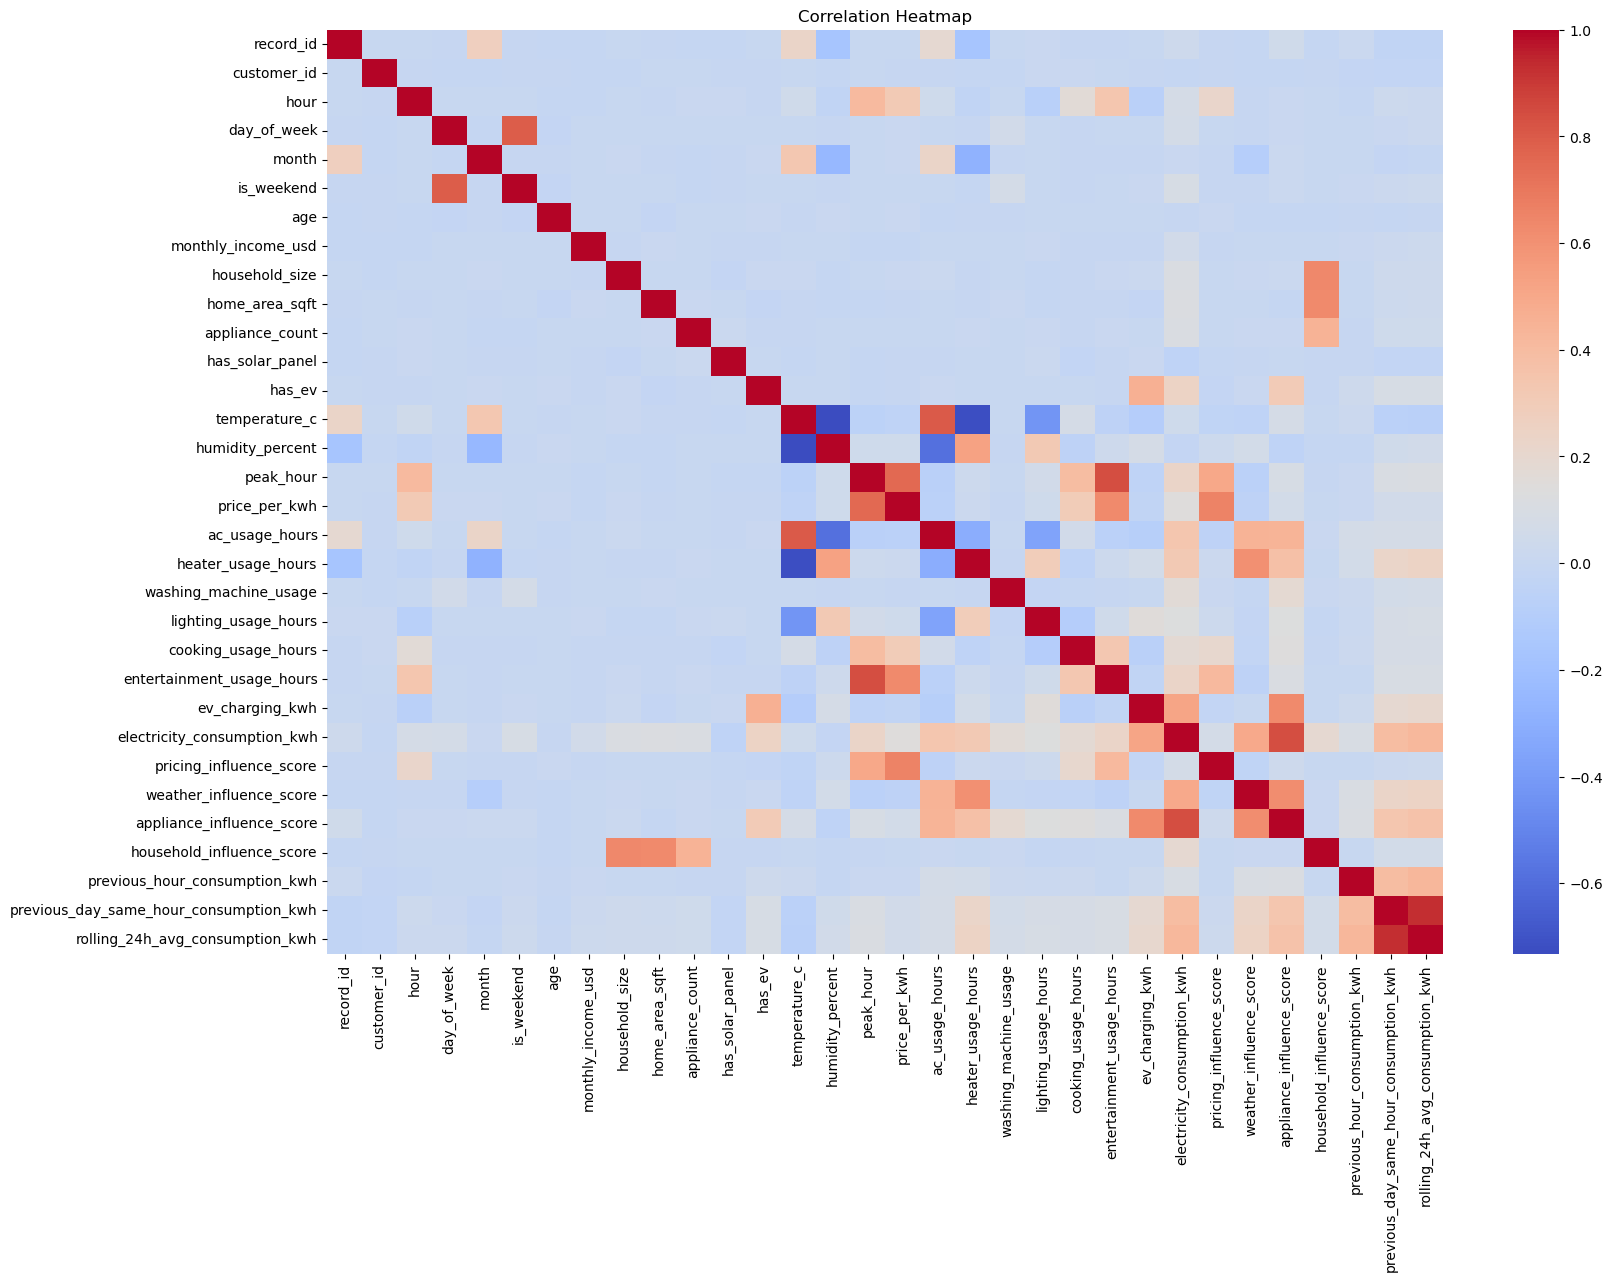

In [11]:
plt.figure(figsize=(18,12))

numeric_df = df.select_dtypes(include=["int64","float64"])

corr = numeric_df.corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")

plt.show()

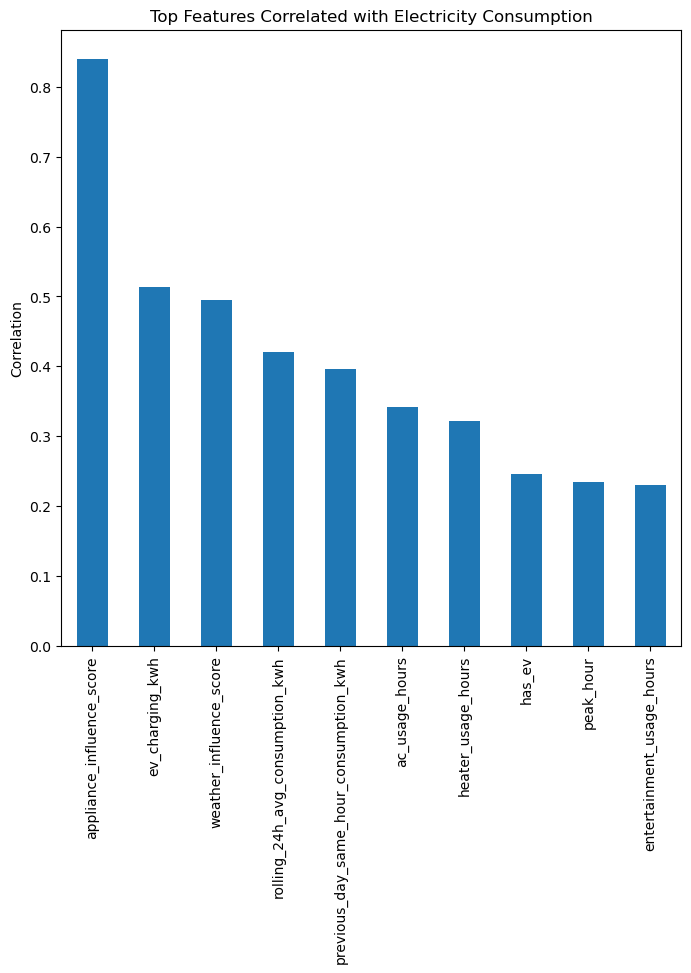

In [12]:
correlation = numeric_df.corr()["electricity_consumption_kwh"]

correlation = correlation.sort_values(ascending=False)

plt.figure(figsize=(8,8))

correlation[1:11].plot(kind="bar")

plt.title("Top Features Correlated with Electricity Consumption")

plt.ylabel("Correlation")

plt.show()

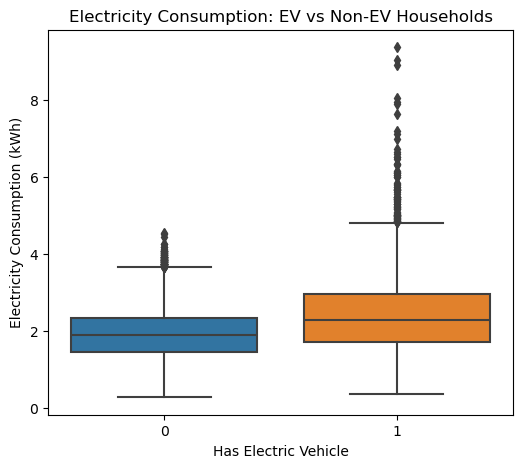

In [13]:
plt.figure(figsize=(6,5))

sns.boxplot(
    x="has_ev",
    y="electricity_consumption_kwh",
    data=df
)

plt.title("Electricity Consumption: EV vs Non-EV Households")

plt.xlabel("Has Electric Vehicle")

plt.ylabel("Electricity Consumption (kWh)")

plt.show()

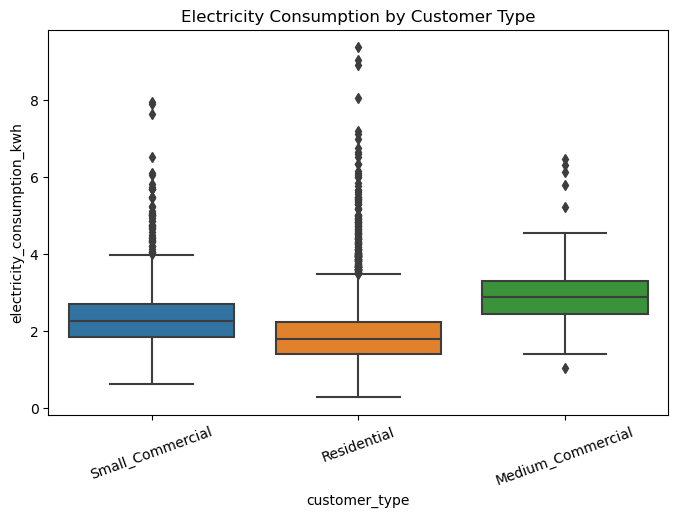

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="customer_type",
    y="electricity_consumption_kwh",
    data=df
)

plt.title("Electricity Consumption by Customer Type")

plt.xticks(rotation=20)

plt.show()

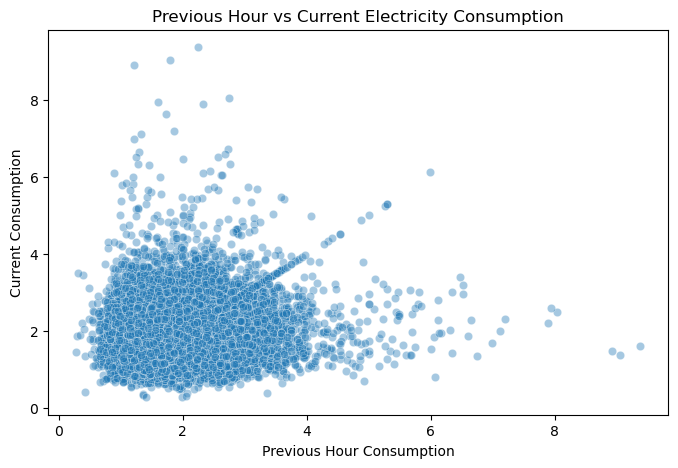

In [15]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="previous_hour_consumption_kwh",
    y="electricity_consumption_kwh",
    data=df,
    alpha=0.4
)

plt.title("Previous Hour vs Current Electricity Consumption")

plt.xlabel("Previous Hour Consumption")

plt.ylabel("Current Consumption")

plt.show()

In [16]:
print("Average Consumption (Solar Panel):")
print(df.groupby("has_solar_panel")["electricity_consumption_kwh"].mean())

print("\n")

print("Average Consumption (EV):")
print(df.groupby("has_ev")["electricity_consumption_kwh"].mean())

print("\n")

print("Average Consumption (Customer Type):")
print(df.groupby("customer_type")["electricity_consumption_kwh"].mean())

print("\n")

print("Average Consumption (Tariff):")
print(df.groupby("tariff_scheme")["electricity_consumption_kwh"].mean())

Average Consumption (Solar Panel):
has_solar_panel
0    2.016404
1    1.918295
Name: electricity_consumption_kwh, dtype: float64


Average Consumption (EV):
has_ev
0    1.941377
1    2.509041
Name: electricity_consumption_kwh, dtype: float64


Average Consumption (Customer Type):
customer_type
Medium_Commercial    2.887533
Residential          1.850521
Small_Commercial     2.322474
Name: electricity_consumption_kwh, dtype: float64


Average Consumption (Tariff):
tariff_scheme
Dynamic_Pricing    1.980164
Flat               2.039974
Peak_Valley        1.978023
Time_of_Use        1.983542
Name: electricity_consumption_kwh, dtype: float64


In [17]:
solar_summary = df.groupby("has_solar_panel")["electricity_consumption_kwh"].mean().reset_index()
solar_summary

,has_solar_panel,electricity_consumption_kwh
0,0,2.016404
1,1,1.918295


# Data Preprocessing

Before training the machine learning models, the dataset is preprocessed. Unnecessary columns are removed, categorical variables are encoded into numerical values, and the data is prepared for model training and evaluation.

In [18]:
# Remove unnecessary columns

df = df.drop(columns=[
    "record_id",
    "customer_id",
    "timestamp"
])

df.head()

,hour,day_of_week,month,is_weekend,season,customer_type,age,monthly_income_usd,household_size,home_area_sqft,...,ev_charging_kwh,electricity_consumption_kwh,pricing_influence_score,weather_influence_score,appliance_influence_score,household_influence_score,previous_hour_consumption_kwh,previous_day_same_hour_consumption_kwh,rolling_24h_avg_consumption_kwh,consumption_behavior_category
0,18,1,1,0,Winter,Small_Commercial,66,3747,1,1355,...,0.000,2.058,11.39,6.702,0.816,3.545,2.058,2.058,2.058,Moderate_Usage
1,9,6,2,1,Winter,Residential,38,5083,2,2535,...,0.000,1.253,5.94,4.538,0.590,3.955,2.058,1.656,1.656,Low_Usage
2,2,2,2,0,Winter,Residential,26,4405,7,1051,...,1.225,3.607,3.44,11.739,2.738,4.461,1.253,2.306,2.306,Peak_Intensive_Usage
3,17,1,2,0,Winter,Residential,59,6962,3,1122,...,0.000,0.662,2.48,5.061,0.280,2.652,3.607,1.895,1.895,Low_Usage
4,20,2,3,0,Spring,Residential,38,3972,4,1892,...,0.000,1.496,0.95,3.762,0.701,4.412,0.662,1.815,1.815,Low_Usage


In [19]:
print(df.columns)

Index(['hour', 'day_of_week', 'month', 'is_weekend', 'season', 'customer_type',
       'age', 'monthly_income_usd', 'household_size', 'home_area_sqft',
       'appliance_count', 'has_solar_panel', 'has_ev', 'tariff_scheme',
       'contract_type', 'temperature_c', 'humidity_percent', 'peak_hour',
       'price_per_kwh', 'ac_usage_hours', 'heater_usage_hours',
       'washing_machine_usage', 'lighting_usage_hours', 'cooking_usage_hours',
       'entertainment_usage_hours', 'ev_charging_kwh',
       'electricity_consumption_kwh', 'pricing_influence_score',
       'weather_influence_score', 'appliance_influence_score',
       'household_influence_score', 'previous_hour_consumption_kwh',
       'previous_day_same_hour_consumption_kwh',
       'rolling_24h_avg_consumption_kwh', 'consumption_behavior_category'],
      dtype='object')


In [20]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical_columns = [
    "season",
    "customer_type",
    "tariff_scheme",
    "contract_type",
    "consumption_behavior_category"
]

for column in categorical_columns:
    df[column] = encoder.fit_transform(df[column])

df.head()

,hour,day_of_week,month,is_weekend,season,customer_type,age,monthly_income_usd,household_size,home_area_sqft,...,ev_charging_kwh,electricity_consumption_kwh,pricing_influence_score,weather_influence_score,appliance_influence_score,household_influence_score,previous_hour_consumption_kwh,previous_day_same_hour_consumption_kwh,rolling_24h_avg_consumption_kwh,consumption_behavior_category
0,18,1,1,0,3,2,66,3747,1,1355,...,0.000,2.058,11.39,6.702,0.816,3.545,2.058,2.058,2.058,2
1,9,6,2,1,3,1,38,5083,2,2535,...,0.000,1.253,5.94,4.538,0.590,3.955,2.058,1.656,1.656,1
2,2,2,2,0,3,1,26,4405,7,1051,...,1.225,3.607,3.44,11.739,2.738,4.461,1.253,2.306,2.306,3
3,17,1,2,0,3,1,59,6962,3,1122,...,0.000,0.662,2.48,5.061,0.280,2.652,3.607,1.895,1.895,1
4,20,2,3,0,1,1,38,3972,4,1892,...,0.000,1.496,0.95,3.762,0.701,4.412,0.662,1.815,1.815,1


In [21]:
# Features
X = df.drop("electricity_consumption_kwh", axis=1)

# Target
y = df["electricity_consumption_kwh"]

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (12000, 34)
Testing Data: (3000, 34)


In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# Model 1: Linear Regression

Linear Regression is used as the baseline model. It predicts household electricity consumption by assuming a linear relationship between the input features and the target variable.

In [24]:
# Import Linear Regression

from sklearn.linear_model import LinearRegression

# Create model
linear_model = LinearRegression()

# Train model
linear_model.fit(X_train_scaled, y_train)

LinearRegression()

In [25]:
# Predict

linear_predictions = linear_model.predict(X_test_scaled)

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

linear_mae = mean_absolute_error(y_test, linear_predictions)

linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))

linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression Results")
print("--------------------------")
print("MAE :", round(linear_mae,3))
print("RMSE:", round(linear_rmse,3))
print("R² Score:", round(linear_r2,3))

Linear Regression Results
--------------------------
MAE : 0.244
RMSE: 0.326
R² Score: 0.803


# Model 2: Random Forest Regressor

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [27]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [28]:
rf_predictions = rf_model.predict(X_test)

In [29]:
rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))

rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Results")
print("--------------------------")
print("MAE :", round(rf_mae,3))
print("RMSE:", round(rf_rmse,3))
print("R² Score:", round(rf_r2,3))

Random Forest Results
--------------------------
MAE : 0.108
RMSE: 0.139
R² Score: 0.964


# Model 3: Gradient Boosting Regressor

Gradient Boosting builds decision trees sequentially, where each new tree improves the errors made by the previous trees. It is widely used for regression problems due to its strong predictive performance.

In [30]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    random_state=42
)

gb_model.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [31]:
gb_predictions = gb_model.predict(X_test)

In [32]:
gb_mae = mean_absolute_error(y_test, gb_predictions)

gb_rmse = np.sqrt(mean_squared_error(y_test, gb_predictions))

gb_r2 = r2_score(y_test, gb_predictions)

print("Gradient Boosting Results")
print("--------------------------")
print("MAE :", round(gb_mae,3))
print("RMSE:", round(gb_rmse,3))
print("R² Score:", round(gb_r2,3))

Gradient Boosting Results
--------------------------
MAE : 0.111
RMSE: 0.137
R² Score: 0.965


In [33]:
comparison = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "MAE":[
        linear_mae,
        rf_mae,
        gb_mae
    ],

    "RMSE":[
        linear_rmse,
        rf_rmse,
        gb_rmse
    ],

    "R² Score":[
        linear_r2,
        rf_r2,
        gb_r2
    ]

})

comparison.round(3)

,Model,MAE,RMSE,R² Score
0,Linear Regression,0.244,0.326,0.803
1,Random Forest,0.108,0.139,0.964
2,Gradient Boosting,0.111,0.137,0.965


# Feature Importance Analysis

After selecting the best-performing machine learning model, feature importance analysis is performed to identify the variables that have the greatest influence on household electricity consumption. Understanding these factors helps energy management companies make better business decisions and provide personalized recommendations to customers.

In [34]:
# Feature Importance

feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": gb_model.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
33,consumption_behavior_category,0.681730
28,appliance_influence_score,0.259719
5,customer_type,0.037046
29,household_influence_score,0.009517
17,peak_hour,0.005935
25,ev_charging_kwh,0.001006
11,has_solar_panel,0.000799
7,monthly_income_usd,0.000683
3,is_weekend,0.000604
1,day_of_week,0.000505


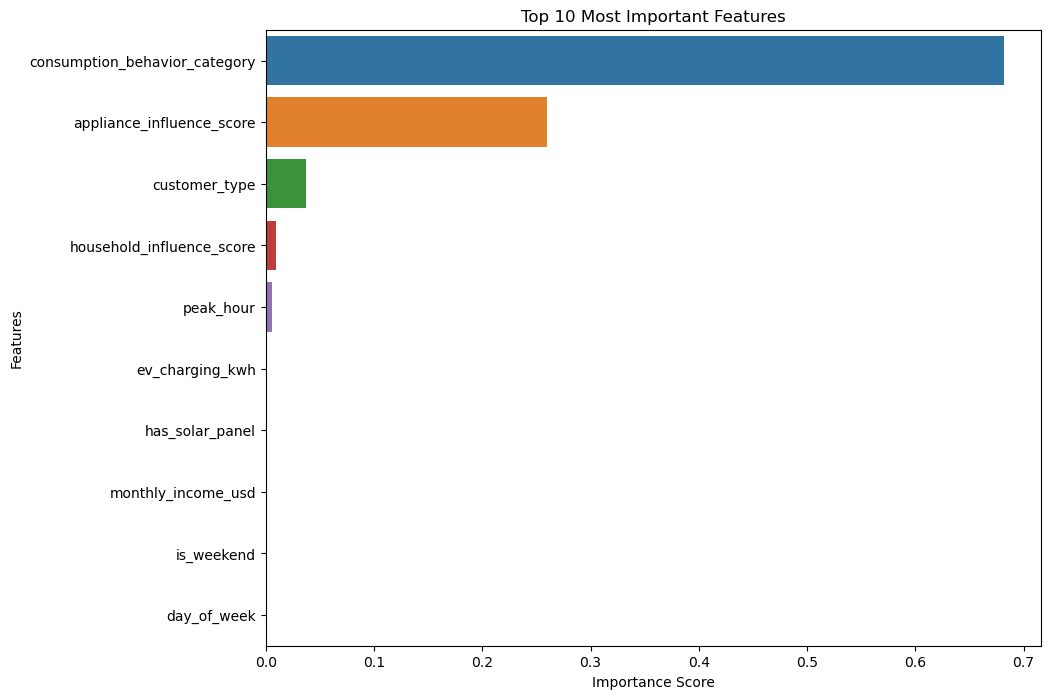

In [35]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Most Important Features")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.show()

# AI-Based Smart Energy Recommendation System

The recommendation system uses household information together with the predicted electricity consumption to provide personalized energy-saving suggestions. The recommendations are designed to improve energy efficiency, reduce electricity costs, and encourage sustainable energy usage.

In [36]:
df_display = pd.read_csv(r'D:\PG\My data sets\power marketing dataset.csv')


In [37]:
def energy_recommendation(row, prediction):

    recommendations = []

    # High consumption
    if prediction > 3:
        recommendations.append("Reduce electricity usage during peak hours.")
        recommendations.append("Monitor high-energy appliances regularly.")

    # Medium consumption
    elif prediction > 2:
        recommendations.append("Shift appliance usage to off-peak tariff periods.")

    # Low consumption
    else:
        recommendations.append("Current electricity usage is efficient. Continue maintaining your energy-saving habits.")

    # Solar recommendation only if consumption is high enough
    if row["has_solar_panel"] == 0 and prediction > 2:
        recommendations.append("Consider installing solar panels to further reduce electricity costs.")

    # EV recommendation
    if row["has_ev"] == 1:
        recommendations.append("Charge the electric vehicle during off-peak hours.")

    # AC
    if row["ac_usage_hours"] > 5:
        recommendations.append("Reduce air conditioner usage during peak demand.")

    # Heater
    if row["heater_usage_hours"] > 4:
        recommendations.append("Reduce heater usage whenever possible.")

    # Tariff
    if row["price_per_kwh"] > 0.25:
        recommendations.append("Shift high-power appliances to lower tariff periods.")

    return recommendations

In [38]:
# Energy Efficiency Score

def efficiency_score(consumption):

    if consumption < 1.5:
        return 95, "Excellent"

    elif consumption < 2.5:
        return 80, "Good"

    elif consumption < 3.5:
        return 65, "Average"

    else:
        return 45, "Needs Improvement"

In [39]:
# Cost Level

def cost_level(consumption):

    if consumption < 1.5:
        return "Low"

    elif consumption < 2.5:
        return "Medium"

    else:
        return "High"

In [40]:
# Carbon Footprint

def carbon_level(consumption):

    if consumption < 1.5:
        return "Low"

    elif consumption < 2.5:
        return "Moderate"

    else:
        return "High"

In [41]:
# Consumption Level

def consumption_level(consumption):

    if consumption < 1.5:
        return "LOW"

    elif consumption < 2.5:
        return "MEDIUM"

    else:
        return "HIGH"

In [42]:
# ============================================
# AI Smart Energy Management Report
# ============================================

# Select a customer
while True:

    try:
        customer_index = int(input("Enter Customer Record Number (0-14999): "))

        if 0 <= customer_index < len(df_display):
            break

        print("Invalid record number. Please enter a number between 0 and 14999.")

    except ValueError:
        print("Please enter a valid integer.")

# Select customer data
sample = X.loc[[customer_index]]

# Predict electricity consumption
prediction = gb_model.predict(sample)[0]

# Display original information
row = df_display.loc[customer_index]

# Calculate score
score, rating = efficiency_score(prediction)

# ============================================
# Print Report
# ============================================

print("="*70)
print("               AI SMART ENERGY MANAGEMENT REPORT")
print("="*70)

print(f"\nCustomer Record ID             : {customer_index}")

print("\nCUSTOMER PROFILE")
print("-"*70)

print(f"Customer Type                  : {row['customer_type']}")
print(f"Household Size                 : {row['household_size']}")
print(f"Monthly Income                 : ${row['monthly_income_usd']}")
print(f"Home Area                      : {row['home_area_sqft']} sqft")
print(f"Solar Panel                    : {'Yes' if row['has_solar_panel']==1 else 'No'}")
print(f"Electric Vehicle               : {'Yes' if row['has_ev']==1 else 'No'}")
print(f"Tariff Scheme                  : {row['tariff_scheme']}")
print(f"Season                         : {row['season']}")
print(f"Temperature                    : {row['temperature_c']} °C")

print("\nPREDICTION")
print("-"*70)

print(f"Predicted Electricity Usage    : {prediction:.2f} kWh")
print(f"Consumption Level              : {consumption_level(prediction)}")

print("\nENERGY ASSESSMENT")
print("-"*70)

print(f"Energy Efficiency Score        : {score}/100")
print(f"Efficiency Rating              : {rating}")
print(f"Estimated Cost Level           : {cost_level(prediction)}")
print(f"Carbon Footprint              : {carbon_level(prediction)}")

print("\nAI RECOMMENDATIONS")
print("-"*70)

recommendations = energy_recommendation(row, prediction)

for i, rec in enumerate(recommendations, start=1):
    print(f"{i}. {rec}")

print("\nBUSINESS INSIGHT")
print("-"*70)

if prediction < 1.5:
    print("The household demonstrates excellent energy efficiency with low predicted electricity consumption.")
    print("Current energy usage is sustainable and no major changes are required.")

elif prediction < 2.5:
    print("The household has moderate electricity consumption.")
    print("Small improvements in appliance usage and energy scheduling could further reduce electricity costs.")

else:
    print("The household has high electricity consumption.")
    print("Implementing energy-saving strategies and renewable energy solutions could significantly reduce electricity costs and carbon emissions.")

print("\n" + "="*70)
print("End of Smart Energy Management Report")
print("="*70)

Enter Customer Record Number (0-14999):  777777


Invalid record number. Please enter a number between 0 and 14999.


Enter Customer Record Number (0-14999):  75


               AI SMART ENERGY MANAGEMENT REPORT

Customer Record ID             : 75

CUSTOMER PROFILE
----------------------------------------------------------------------
Customer Type                  : Small_Commercial
Household Size                 : 7
Monthly Income                 : $1945
Home Area                      : 2676 sqft
Solar Panel                    : No
Electric Vehicle               : No
Tariff Scheme                  : Flat
Season                         : Autumn
Temperature                    : 31.18 °C

PREDICTION
----------------------------------------------------------------------
Predicted Electricity Usage    : 3.07 kWh
Consumption Level              : HIGH

ENERGY ASSESSMENT
----------------------------------------------------------------------
Energy Efficiency Score        : 65/100
Efficiency Rating              : Average
Estimated Cost Level           : High
Carbon Footprint              : High

AI RECOMMENDATIONS
-------------------------------------